# Paper Figure 2: 시퀀스 유사도 수준별 경로 매칭 예시

GTFS 기반 중간정류장 확장 및 정류장명 정규화 후 LCS 비율로 비교한 결과.
- (a) LCS=1.0: 완전 일치
- (b) LCS≈0.75: 주요 노선 일치, 일부 구간 상이
- (c) LCS≈0.50: OD 동일, 중간 경로 상이
- (d) LCS≈0.25: 수단 조합 상이

In [1]:
# -*- coding: utf-8 -*-
import sys, sqlite3, pickle, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib import font_manager, rc
import contextily as ctx
from pyproj import Transformer

warnings.filterwarnings('ignore')

# 한글 폰트
font_path = 'C:/Windows/Fonts/malgun.ttf'
if Path(font_path).exists():
    font_manager.fontManager.addfont(font_path)
    rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

ROOT = Path('../../').resolve()
DATA_DIR = ROOT / 'data'
IMG_DIR = ROOT / 'images'
IMG_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(Path('.').resolve()))
from module.similarity import (
    parse_smartcard_trip, compute_all_metrics, compute_composite_similarity,
    _normalize_stops_for_comparison, _lcs_length
)

# WGS84 → Web Mercator 변환 (contextily용)
transformer = Transformer.from_crs('EPSG:4326', 'EPSG:3857', always_xy=True)

def to_mercator(lon, lat):
    """위경도 → Web Mercator"""
    x, y = transformer.transform(lon, lat)
    return x, y

In [2]:
# ── 데이터 로드 ──
cache_db = DATA_DIR / 'training_set' / 'otp_cache.db'
conn = sqlite3.connect(str(cache_db))

tcn_path = DATA_DIR / 'tcn' / '20250217' / 'TCN_20250217_route.parquet'
tcn = pd.read_parquet(tcn_path)

training = pd.read_parquet(DATA_DIR / 'training_set' / 'route_choice_training.parquet')

print(f'TCN trips: {len(tcn):,}')
print(f'Training set: {len(training):,} rows')
print(f'Unique ODs: {training["od_pair"].nunique():,}')

TCN trips: 12,999,778
Training set: 1,973,353 rows
Unique ODs: 530,689


In [3]:
# ── 각 LCS 수준별 대표 OD 탐색 ──
target_levels = [
    ('a', 1.00, 0.02, False),
    ('b', 0.75, 0.05, False),
    ('c', 0.50, 0.05, False),
    ('d', 0.25, 0.15, True),   # 넓은 tolerance + 모드 상이 필터
]

selected_examples = []
tcn_ods = set(tcn['od_pair'].unique())

for label, target_lcs, tol, require_diff_mode in target_levels:
    mask = (
        (training['sim_sequence'] >= target_lcs - tol) &
        (training['sim_sequence'] <= target_lcs + tol) &
        (training['choice_prob'] > 0.01) &
        (training['n_total'] >= 20)
    )
    candidates = training[mask].copy()
    candidates = candidates[candidates['od_pair'].isin(tcn_ods)]

    if require_diff_mode:
        # 모드가 다른 대안 (sim_mode=0.5 = 부분 겹침, e.g. bus+train vs train)
        candidates = candidates[candidates['sim_mode'] <= 0.5]
        candidates = candidates.sort_values(['sim_route', 'n_total'],
                                             ascending=[True, False])
    else:
        candidates = candidates.sort_values('n_total', ascending=False)

    found = False
    for _, row in candidates.iterrows():
        od = row['od_pair']
        cur = conn.cursor()
        cur.execute('SELECT data FROM otp_cache WHERE od_pair = ?', (od,))
        result = cur.fetchone()
        if result is None:
            continue

        otp_data = pickle.loads(result[0])
        alt_idx = int(row['alt_idx'])
        if alt_idx >= len(otp_data['otp_parsed']):
            continue
        otp_parsed = otp_data['otp_parsed'][alt_idx]

        # OTP stop_coords가 최소 2개 있어야 지도 표시 가능
        if len(otp_parsed.get('stop_coords', [])) < 2:
            continue

        selected_examples.append({
            'label': label,
            'target_lcs': target_lcs,
            'od_pair': od,
            'alt_idx': alt_idx,
            'sim_sequence': row['sim_sequence'],
            'sim_mode': row.get('sim_mode', 0),
            'n_total': row['n_total'],
            'choice_prob': row['choice_prob'],
        })
        print(f'({label}) LCS≈{target_lcs:.2f}: od={od}, alt={alt_idx}, '
              f'sim_seq={row["sim_sequence"]:.3f}, sim_mode={row.get("sim_mode",0):.3f}, '
              f'n={row["n_total"]:.0f}, routes={otp_parsed["routes"]}')
        found = True
        break

    if not found:
        print(f'({label}) LCS≈{target_lcs}: *** 적합한 예시 없음 ***')

print(f'\n선택된 예시: {len(selected_examples)}개')

(a) LCS≈1.00: od=216_217, alt=0, sim_seq=0.999, sim_mode=1.000, n=15498, routes=[' 2호선']
(b) LCS≈0.75: od=1003_1264, alt=1, sim_seq=0.750, sim_mode=1.000, n=2921, routes=['공항철도', ' 1호선']
(c) LCS≈0.50: od=1713_1719, alt=1, sim_seq=0.500, sim_mode=0.500, n=6276, routes=['46', ' 1호선']
(d) LCS≈0.25: od=2733_426, alt=2, sim_seq=0.333, sim_mode=0.500, n=428, routes=['470', ' 4호선', ' 7호선']

선택된 예시: 4개


In [4]:
# ── LCS 인덱스 역추적 함수 ──
def get_lcs_indices(seq1, seq2):
    m, n = len(seq1), len(seq2)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if seq1[i-1] == seq2[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    idx1, idx2 = [], []
    i, j = m, n
    while i > 0 and j > 0:
        if seq1[i-1] == seq2[j-1]:
            idx1.append(i-1)
            idx2.append(j-1)
            i -= 1
            j -= 1
        elif dp[i-1][j] > dp[i][j-1]:
            i -= 1
        else:
            j -= 1
    return list(reversed(idx1)), list(reversed(idx2))


def extract_coords(parsed, source='otp'):
    """
    parsed dict에서 (name, lat, lon) 좌표 시퀀스 추출.
    OTP: stop_coords + stops 매핑
    SC: od_coords + stop_coords 결합
    """
    coords = []
    stops = parsed.get('stops', [])
    
    if source == 'otp':
        stop_coords = parsed.get('stop_coords', [])
        for i, (lat, lon) in enumerate(stop_coords):
            name = stops[i] if i < len(stops) else f'stop_{i}'
            if lat is not None and lon is not None:
                coords.append((name, float(lat), float(lon)))
    else:  # sc
        od = parsed.get('od_coords', {})
        # 출발지
        if od.get('o_lat') and od.get('o_lon'):
            name = stops[0] if stops else 'O'
            coords.append((name, float(od['o_lat']), float(od['o_lon'])))
        # 중간 환승 정류장
        for i, c in enumerate(parsed.get('stop_coords', [])):
            if c and len(c) >= 2:
                idx = i + 1
                name = stops[idx] if idx < len(stops) else f'transfer_{i}'
                coords.append((name, float(c[0]), float(c[1])))
        # 도착지
        if od.get('d_lat') and od.get('d_lon'):
            name = stops[-1] if len(stops) > 1 else 'D'
            coords.append((name, float(od['d_lat']), float(od['d_lon'])))
    
    return coords

In [5]:
# ── 각 예시의 SC/OTP 데이터 로드 및 좌표 추출 ──
examples_data = []

for ex in selected_examples:
    od = ex['od_pair']
    alt_idx = ex['alt_idx']

    # OTP 캐시
    cur = conn.cursor()
    cur.execute('SELECT data FROM otp_cache WHERE od_pair = ?', (od,))
    otp_data = pickle.loads(cur.fetchone()[0])
    otp_parsed = otp_data['otp_parsed'][alt_idx]

    # SC (TCN)
    sc_trips = tcn[tcn['od_pair'] == od]
    sc_sample = sc_trips.iloc[0]
    sc_parsed = parse_smartcard_trip(sc_sample)

    # 좌표 추출
    otp_coords = extract_coords(otp_parsed, source='otp')
    sc_coords = extract_coords(sc_parsed, source='sc')

    # 정류장 시퀀스 (LCS용)
    otp_stops = otp_parsed.get('full_stops') or otp_parsed['stops']
    sc_stops = sc_parsed.get('full_stops') or sc_parsed['stops']
    norm_otp, norm_sc = _normalize_stops_for_comparison(otp_stops, sc_stops)
    lcs_idx_otp, lcs_idx_sc = get_lcs_indices(norm_otp, norm_sc)

    print(f"({ex['label']}) OD={od}, alt={alt_idx}, sim_seq={ex['sim_sequence']:.3f}")
    print(f"    OTP coords: {len(otp_coords)} points — {[c[0] for c in otp_coords]}")
    print(f"    SC  coords: {len(sc_coords)} points — {[c[0] for c in sc_coords]}")
    print(f"    OTP routes: {otp_parsed['routes']}, SC routes: {sc_parsed['routes']}")
    print()

    examples_data.append({
        'label': ex['label'],
        'target_lcs': ex['target_lcs'],
        'od_pair': od,
        'otp_coords': otp_coords,  # [(name, lat, lon), ...]
        'sc_coords': sc_coords,
        'otp_stops': otp_stops,
        'sc_stops': sc_stops,
        'lcs_idx_otp': lcs_idx_otp,
        'lcs_idx_sc': lcs_idx_sc,
        'sim_sequence': ex['sim_sequence'],
        'otp_routes': otp_parsed['routes'],
        'sc_routes': sc_parsed['routes'],
        'otp_modes': sorted(otp_parsed['modes']),
        'sc_modes': sorted(sc_parsed['modes']),
    })

(a) OD=216_217, alt=0, sim_seq=0.999
    OTP coords: 2 points — ['잠실(송파구청)', '잠실새내']
    SC  coords: 2 points — ['잠실(송파구청)', '잠실새내']
    OTP routes: [' 2호선'], SC routes: ['2호선']

(b) OD=1003_1264, alt=1, sim_seq=0.750
    OTP coords: 4 points — ['용산', '서울역(지하)', '서울역', '홍대입구']
    SC  coords: 3 points — ['용산', '서울', '홍대입구']
    OTP routes: ['공항철도', ' 1호선'], SC routes: ['1호선']

(c) OD=1713_1719, alt=1, sim_seq=0.500
    OTP coords: 4 points — ['수원', '병점', '병점역.화성청년지원센터', '오산역환승센터1층(1승강장)']
    SC  coords: 2 points — ['수원', '오산']
    OTP routes: ['46', ' 1호선'], SC routes: ['1호선']

(d) OD=2733_426, alt=2, sim_seq=0.333
    OTP coords: 6 points — ['학동', '논현', '신사역', '국가인권위.안중근활동터', '명동', '서울역']
    SC  coords: 3 points — ['학동', '노원', '서울']
    OTP routes: ['470', ' 4호선', ' 7호선'], SC routes: ['7호선']



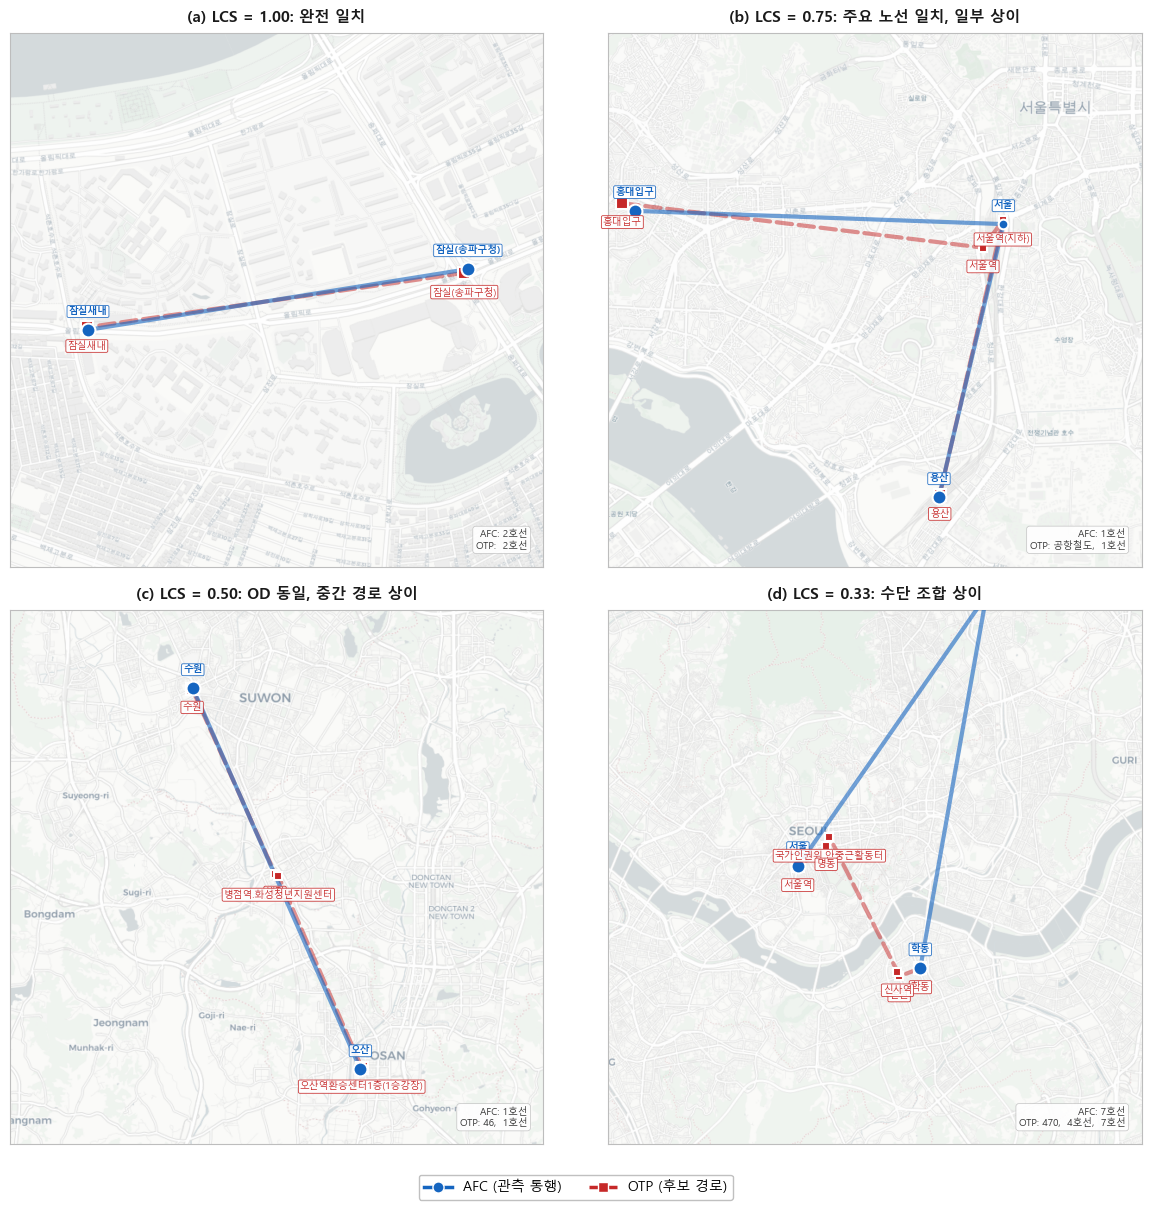

Saved: D:\Folder\Research\6.route_choice_simulation\images\fig2_sequence_similarity_examples.png


In [6]:
# ── Figure 2: 지도 기반 경로 비교 (2×2 정사각형 패널) ──

# 색상
C_AFC = '#1565C0'       # AFC: 진한 파랑
C_OTP = '#C62828'       # OTP: 진한 빨강

panel_titles = {
    'a': '(a) LCS = {:.2f}: 완전 일치',
    'b': '(b) LCS = {:.2f}: 주요 노선 일치, 일부 상이',
    'c': '(c) LCS = {:.2f}: OD 동일, 중간 경로 상이',
    'd': '(d) LCS = {:.2f}: 수단 조합 상이',
}


def draw_map_panel(ax, ex):
    """지도 위에 AFC/OTP 경로를 정사각형 패널로 그림"""
    otp_coords = ex['otp_coords']
    sc_coords = ex['sc_coords']
    label = ex['label']
    sim_seq = ex['sim_sequence']

    if not otp_coords or not sc_coords:
        ax.text(0.5, 0.5, 'No coordinates', transform=ax.transAxes, ha='center')
        ax.set_title(panel_titles[label].format(sim_seq))
        return

    # ── Web Mercator로 변환 ──
    sc_pts = [(n, *to_mercator(lon, lat)) for n, lat, lon in sc_coords]
    otp_pts = [(n, *to_mercator(lon, lat)) for n, lat, lon in otp_coords]

    all_x = [p[1] for p in sc_pts + otp_pts]
    all_y = [p[2] for p in sc_pts + otp_pts]

    # 범위 계산 (정사각형, 여유)
    cx, cy = np.mean(all_x), np.mean(all_y)
    span = max(max(all_x) - min(all_x), max(all_y) - min(all_y))
    span = max(span, 1500)  # 최소 1.5km
    margin = span * 0.4
    half = (span + margin) / 2

    ax.set_xlim(cx - half, cx + half)
    ax.set_ylim(cy - half, cy + half)
    ax.set_aspect('equal')

    # ── 배경 지도 ──
    try:
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron,
                        zoom='auto', attribution='')
    except Exception:
        ax.set_facecolor('#F5F5F5')

    # ── AFC 경로 (파란 실선) ──
    if len(sc_pts) >= 2:
        sc_x = [p[1] for p in sc_pts]
        sc_y = [p[2] for p in sc_pts]
        ax.plot(sc_x, sc_y, color=C_AFC, linewidth=3, alpha=0.6,
                zorder=4, solid_capstyle='round')

    # AFC 정류장 마커 + 라벨 (위쪽)
    for i, (name, x, y) in enumerate(sc_pts):
        ms = 10 if (i == 0 or i == len(sc_pts) - 1) else 7
        ax.plot(x, y, marker='o', markersize=ms,
                color=C_AFC, markeredgecolor='white', markeredgewidth=1.5,
                zorder=6)
        ax.annotate(name, (x, y), xytext=(0, 10),
                    textcoords='offset points',
                    fontsize=7, fontweight='bold', color=C_AFC,
                    ha='center', va='bottom',
                    bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                              edgecolor=C_AFC, alpha=0.9, linewidth=0.6),
                    zorder=7)

    # ── OTP 경로 (빨간 점선) ──
    if len(otp_pts) >= 2:
        otp_x = [p[1] for p in otp_pts]
        otp_y = [p[2] for p in otp_pts]
        ax.plot(otp_x, otp_y, color=C_OTP, linewidth=3, alpha=0.5,
                linestyle='--', zorder=3, dash_capstyle='round')

    # OTP 정류장 마커 + 라벨 (아래쪽)
    for i, (name, x, y) in enumerate(otp_pts):
        ms = 9 if (i == 0 or i == len(otp_pts) - 1) else 6
        ax.plot(x, y, marker='s', markersize=ms,
                color=C_OTP, markeredgecolor='white', markeredgewidth=1.5,
                zorder=5)
        ax.annotate(name, (x, y), xytext=(0, -10),
                    textcoords='offset points',
                    fontsize=7, color=C_OTP,
                    ha='center', va='top',
                    bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                              edgecolor=C_OTP, alpha=0.9, linewidth=0.6),
                    zorder=7)

    # ── 패널 제목 ──
    title = panel_titles[label].format(sim_seq)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8, color='#1A1A1A')

    # ── 축 정리 ──
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)
        spine.set_color('#BDBDBD')

    # ── 노선 정보 (우하단) ──
    sc_info = ', '.join(ex['sc_routes'])
    otp_info = ', '.join(ex['otp_routes'])
    info_text = f'AFC: {sc_info}\nOTP: {otp_info}'
    ax.text(0.97, 0.03, info_text, transform=ax.transAxes,
            fontsize=7, ha='right', va='bottom',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='#BDBDBD', alpha=0.9, linewidth=0.5),
            color='#333', zorder=10)


# ══════════════════════════════════════════════
# 2×2 그림 생성
# ══════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes_flat = axes.flatten()

for i, ex in enumerate(examples_data):
    draw_map_panel(axes_flat[i], ex)

# ── 공통 범례 ──
legend_elements = [
    Line2D([0], [0], marker='o', color=C_AFC, linewidth=2.5,
           markeredgecolor='white', markersize=8, label='AFC (관측 통행)'),
    Line2D([0], [0], marker='s', color=C_OTP, linewidth=2.5,
           markeredgecolor='white', markersize=7, linestyle='--',
           label='OTP (후보 경로)'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=10,
           bbox_to_anchor=(0.5, -0.01), frameon=True,
           edgecolor='#BDBDBD', fancybox=True, framealpha=0.95)

plt.tight_layout(rect=[0, 0.03, 1, 1], h_pad=1.5, w_pad=1.5)
fig.savefig(str(IMG_DIR / 'fig2_sequence_similarity_examples.png'),
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {IMG_DIR / "fig2_sequence_similarity_examples.png"}')

In [7]:
# ── 정리 ──
conn.close()
print('Done!')

Done!
